In [2]:
import pickle

In [3]:
!pip install -q evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.8 MB/s eta 0:00:00


In [6]:
import pickle

# Example: Assuming 'model' is your trained model object
filename = 'sentiment analysis model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model, file)


In [7]:
import torch.nn.functional as F

def predict_sentiment_verbose(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    confidence = probs.max().item()
    pred = torch.argmax(probs, dim=1).item()
    return ("positive" if pred == 1 else "negative"), confidence

print(predict_sentiment_verbose("I think the class is useful."))


('positive', 0.9394863843917847)


She explains things slow and rarely no smooth students.  [negative]
I dey feel lost and negative for class.  [negative]
I dey feel lost and chaotic for class.  [negative]
The oga teacher dey manipulative and careless.  [negative]
Attendance was taken at the beginning.  [neutral]


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Text: I think the class is useful and well-organized.
Predicted: positive

Text: I find the lectures confusing and hard to follow.
Predicted: negative

Text: The class is okay, neither good nor bad.
Predicted: neutral



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confusion Matrix:
 [[78  0  0]
 [ 0 48  0]
 [ 0  0 54]]
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        78
     neutral       1.00      1.00      1.00        48
    positive       1.00      1.00      1.00        54

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



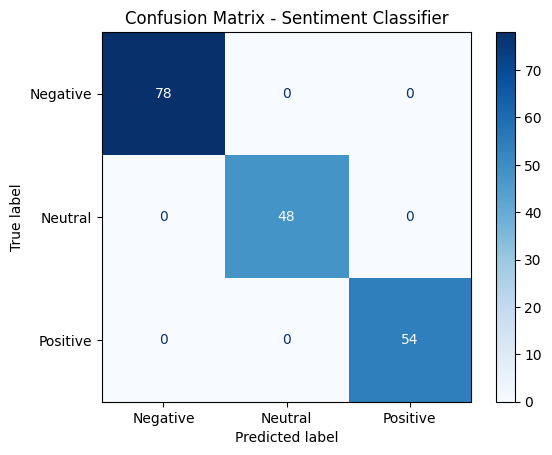

In [5]:
# 1. Install dependencies
!pip install -q transformers datasets scikit-learn evaluate

# 2. Imports
import random
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np


random.seed(42)

# Original positive templates
positive_templates = [
    "The teacher is very {} and {}.",
    "I really {} the way the class is {}.",
    "She always {} and {} the students.",
    "His {} teaching style helps me {}.",
    "Always {} to help and {} questions.",
    "Very {} and {} about teaching.",
    "The course is {} and {}.",
    "She explains things {} and always {} students.",
    "I feel {} and {} in class.",
    "He is the most {} and {} instructor I've had."
]

# Nigerian English / Pidgin positive templates
nigerian_pidgin_positive_templates = [
    "The oga teacher sabi well well, e dey {} and {}.",
    "I dey really {} how the class dey {}.",
    "She dey always {} and dey {} the pikin dem.",
    "Him teaching style na correct one, e dey help me {}.",
    "E dey always {} to assist and {} any question.",
    "Na very {} and {} person e be for teaching.",
    "This course na the best, e dey {} and {}.",
    "She dey explain well and dey always {} students.",
    "I dey feel comfortable and {} anytime for class.",
    "Na the most {} and {} lecturer I don ever see."
]

# Original positive words (pairs)
positive_words = [
    ("helpful", "clear"), ("appreciate", "structured"), ("encourages", "supports"), ("unique", "learn"),
    ("available", "answers"), ("motivated", "passionate"), ("engaging", "informative"), ("well", "supports"),
    ("comfortable", "motivated"), ("inspiring", "dedicated"), ("organized", "thoughtful"), ("respectful", "caring"),
    ("efficient", "skilled"), ("responsive", "professional"), ("articulate", "kind"), ("supportive", "positive"),
    ("effective", "brilliant"), ("patient", "understanding"), ("knowledgeable", "funny"), ("reliable", "helpful"),
    ("attentive", "generous"), ("open", "fair"), ("polite", "welcoming"), ("clear", "encouraging"),
    ("honest", "humble"), ("devoted", "smart"), ("uplifting", "balanced"), ("focused", "friendly"),
    ("brave", "steady"), ("passionate", "wise"), ("creative", "inspiring"), ("meticulous", "energetic"),
    ("sincere", "warm"), ("fair", "engaging"), ("dedicated", "cheerful"), ("friendly", "open-minded"),
    ("fun", "productive"), ("amazing", "attentive"), ("genuine", "interactive"), ("caring", "confident"),
    ("practical", "wise"), ("prepared", "adaptable"), ("positive", "authentic"), ("strategic", "resourceful"),
    ("calm", "understanding"), ("bold", "kind-hearted"), ("enthusiastic", "diligent"), ("focused", "informed"),
    ("cheerful", "supportive"), ("patient", "creative"), ("warm", "organized"), ("trustworthy", "flexible"),
    ("gracious", "respectful"), ("proactive", "dedicated"), ("joyful", "sharp"), ("quick", "efficient"),
    ("insightful", "attentive"), ("thoughtful", "encouraging"), ("versatile", "capable"), ("calm", "motivated"),
    ("wise", "present"), ("consistent", "sincere"), ("involved", "lively"), ("active", "confident"),
    ("focused", "engaged"), ("rational", "strategic"), ("goal-oriented", "empowering"), ("adaptive", "approachable"),
    ("experienced", "inspiring"), ("respectful", "thorough"), ("dynamic", "grounded"), ("resourceful", "enthusiastic"),
    ("connected", "coherent"), ("sympathetic", "realistic"), ("stable", "proactive"), ("intuitive", "firm"),
    ("balanced", "visionary"), ("clear-headed", "driven"), ("humble", "creative"), ("serene", "expressive"),
    ("dedicated", "generous"), ("fun-loving", "detailed"), ("skilled", "organized"), ("empowering", "motivating"),
    ("witty", "kind"), ("encouraging", "responsive"), ("attentive", "open"), ("motivated", "focused"),
    ("brilliant", "authentic"), ("capable", "sensitive"), ("organized", "calm"), ("insightful", "balanced"),
    ("fair", "relatable"), ("reliable", "quick-thinking"), ("profound", "steady"), ("welcoming", "joyful")
]

# Nigerian English / Pidgin positive words
nigerian_pidgin_positive_words = [
    ("beta", "correct"), ("like", "well arranged"), ("encourage", "support"), ("special", "learn"),
    ("ready", "answer"), ("sharp", "passionate"), ("interesting", "informative"), ("clear", "support"),
    ("soft", "motivated"), ("inspiring", "ready"), ("arranged", "kind"), ("respectful", "caring"),
    ("fast", "skillful"), ("quick", "professional"), ("good talker", "kind-hearted"), ("supportive", "sweet"),
    ("effective", "sharp"), ("patient", "understand"), ("wise", "funny"), ("dependable", "helpful"),
    ("attentive", "generous"), ("open", "fair"), ("polite", "friendly"), ("clear", "encouraging"),
    ("honest", "humble"), ("devoted", "smart"), ("uplifting", "balanced"), ("focused", "friendly"),
    ("brave", "steady"), ("passionate", "wise"), ("creative", "inspiring"), ("careful", "energetic"),
    ("sincere", "warm"), ("fair", "engaging"), ("dedicated", "cheerful"), ("friendly", "open-minded"),
    ("fun", "productive"), ("amazing", "attentive"), ("real", "interactive"), ("caring", "confident"),
    ("practical", "wise"), ("prepared", "adaptable"), ("positive", "true"), ("strategic", "resourceful"),
    ("calm", "understanding"), ("bold", "kind-hearted"), ("enthusiastic", "diligent"), ("focused", "informed"),
    ("cheerful", "supportive"), ("patient", "creative"), ("warm", "arranged"), ("trustworthy", "flexible"),
    ("gracious", "respectful"), ("proactive", "dedicated"), ("joyful", "sharp"), ("quick", "efficient"),
    ("insightful", "attentive"), ("thoughtful", "encouraging"), ("versatile", "capable"), ("calm", "motivated"),
    ("wise", "present"), ("steady", "sincere"), ("involved", "lively"), ("active", "confident"),
    ("focused", "engaged"), ("rational", "strategic"), ("goal-oriented", "empowering"), ("adaptable", "friendly"),
    ("experienced", "inspiring"), ("respectful", "thorough"), ("dynamic", "grounded"), ("resourceful", "sharp"),
    ("connected", "coherent"), ("sympathetic", "realistic"), ("stable", "proactive"), ("intuitive", "firm"),
    ("balanced", "visionary"), ("clear-headed", "driven"), ("humble", "creative"), ("quiet", "expressive"),
    ("dedicated", "generous"), ("fun-loving", "detailed"), ("skilled", "arranged"), ("empowering", "motivating"),
    ("witty", "kind"), ("encouraging", "responsive"), ("attentive", "open"), ("motivated", "focused"),
    ("brilliant", "true"), ("capable", "sensitive"), ("organized", "calm"), ("insightful", "balanced"),
    ("fair", "relatable"), ("reliable", "quick-thinking"), ("deep", "steady"), ("welcoming", "joyful")
]

# Original negative templates
negative_templates = [
    "The teacher is very {} and {}.",
    "I really {} the way the class is {}.",
    "She always {} and {} the students.",
    "His {} teaching style makes it hard to {}.",
    "Never {} to help or {} questions.",
    "Very {} and seems {} about teaching.",
    "The course is {} and {}.",
    "She explains things {} and rarely {} students.",
    "I feel {} and {} in class.",
    "He is the most {} and {} instructor I've had."
]

# Nigerian English / Pidgin negative templates
nigerian_pidgin_negative_templates = [
    "The oga teacher dey {} and {}.",
    "I no too {} the way the class dey {}.",
    "She dey always {} and dey {} the pikin dem.",
    "Him teaching style na wahala, e dey hard to {}.",
    "No dey ever {} to help or {} question.",
    "E be like say e no too {} about teaching.",
    "The course na {} and {} one.",
    "She dey explain anyhow and no dey {} students well.",
    "I dey feel lost and {} for class.",
    "Na the most {} and {} lecturer I don meet."
]

# Original negative words
negative_words = [
    ("rude", "unprepared"), ("dislike", "disorganized"), ("ignores", "criticizes"), ("confusing", "follow"),
    ("bothers", "answer"), ("boring", "uninterested"), ("messy", "useless"), ("poorly", "acknowledges"),
    ("lost", "anxious"), ("frustrating", "inconsistent"), ("angry", "slow"), ("cold", "dismissive"),
    ("moody", "unclear"), ("distracted", "impatient"), ("hostile", "rushed"), ("negative", "critical"),
    ("unfriendly", "erratic"), ("stressed", "uncaring"), ("inattentive", "clueless"), ("disruptive", "rude"),
    ("mean", "harsh"), ("arrogant", "offensive"), ("lazy", "uncertain"), ("uninspiring", "flat"),
    ("dull", "apathetic"), ("unhelpful", "distant"), ("inconsistent", "forgetful"), ("vague", "passive"),
    ("intimidating", "condescending"), ("careless", "argumentative"), ("insensitive", "harsh"),
    ("fake", "dismissive"), ("erratic", "impulsive"), ("conflicted", "rigid"), ("negative", "closed"),
    ("unavailable", "unconcerned"), ("slow", "awkward"), ("mechanical", "tense"), ("apathetic", "disrespectful"),
    ("detached", "biased"), ("judgmental", "weak"), ("emotionless", "withdrawn"), ("harsh", "misleading"),
    ("manipulative", "careless"), ("unstable", "cold"), ("angry", "aggressive"), ("forgetful", "confused"),
    ("unskilled", "hostile"), ("indifferent", "poor"), ("low-energy", "unstructured"), ("uncaring", "rushed"),
    ("short-tempered", "disrespectful"), ("loud", "difficult"), ("vulgar", "impolite"), ("unpredictable", "impersonal"),
    ("discouraging", "rigid"), ("defensive", "selfish"), ("irritated", "disengaged"), ("jealous", "bitter"),
    ("arrogant", "grumpy"), ("sloppy", "careless"), ("reckless", "negligent"), ("fake", "confused"),
    ("strict", "close-minded"), ("bitter", "rigid"), ("gruff", "silent"), ("absent", "snappy"),
    ("complaining", "dull"), ("weak", "uncertain"), ("aloof", "uptight"), ("dry", "passive"),
    ("unpleasant", "mean"), ("depressing", "insincere"), ("blunt", "insecure"), ("lazy", "late"),
    ("dishonest", "impolite"), ("disinterested", "unavailable"), ("dismissive", "annoyed"), ("distracted", "jealous"),
    ("grumpy", "defensive"), ("unstable", "unfamiliar"), ("forgetful", "unresponsive"), ("nonchalant", "bored"),
    ("loud", "insensitive"), ("cold", "unwelcoming"), ("hostile", "mean"), ("awkward", "boring"),
    ("bitter", "tiring"), ("apathetic", "sour"), ("tense", "unrealistic"), ("unfriendly", "monotone"),
    ("pushy", "unclear"), ("insecure", "distant"), ("chaotic", "mean"), ("unreliable", "unfocused"),
    ("controlling", "unpleasant"), ("demeaning", "dismissive"), ("rude", "inflexible"), ("nagging", "negative")
]

# Nigerian English / Pidgin negative words
nigerian_pidgin_negative_words = [
    ("rude", "no ready"), ("no like", "scatterbrain"), ("no dey listen", "talk anyhow"), ("confusing", "hard to follow"),
    ("bother", "no answer"), ("boring", "no care"), ("messy", "useless"), ("no sabi", "no pay attention"),
    ("lost", "worried"), ("frustrating", "no steady"), ("angry", "slow"), ("cold", "no gree"),
    ("moody", "no clear"), ("distracted", "no patient"), ("hostile", "rush"), ("negative", "bad talk"),
    ("no friendly", "no sure"), ("stress", "no care"), ("no attentive", "confused"), ("disruptive", "rude"),
    ("mean", "hard"), ("arrogant", "offensive"), ("lazy", "no sure"), ("no inspire", "flat"),
    ("dull", "no care"), ("no help", "far away"), ("no steady", "forget"), ("no clear", "soft"),
    ("fear", "talk anyhow"), ("no care", "fight"), ("no feel", "hard"),
    ("fake", "no gree"), ("no steady", "rush"), ("confused", "hard"), ("no good", "closed"),
    ("no dey available", "no care"), ("slow", "no smooth"), ("mechanical", "tight"), ("no care", "no respect"),
    ("far away", "biased"), ("judgmental", "weak"), ("no feel", "hide"), ("hard", "no true"),
    ("trick", "no care"), ("no steady", "cold"), ("angry", "aggressive"), ("forget", "confused"),
    ("no skill", "hostile"), ("no care", "poor"), ("low energy", "scatter"), ("no care", "rush"),
    ("short temper", "no respect"), ("loud", "hard"), ("bad talk", "no polite"), ("no sure", "no care"),
    ("discourage", "no change"), ("defend", "selfish"), ("irritated", "no join"), ("jealous", "bitter"),
    ("arrogant", "grumpy"), ("sloppy", "no care"), ("reckless", "no care"), ("fake", "confused"),
    ("strict", "close-minded"), ("bitter", "hard"), ("rough", "quiet"), ("absent", "snap"),
    ("complain", "dull"), ("weak", "no sure"), ("aloof", "uptight"), ("dry", "soft"),
    ("no friendly", "mean"), ("depressing", "no true"), ("blunt", "no sure"), ("lazy", "late"),
    ("dishonest", "no polite"), ("no care", "no available"), ("dismiss", "annoyed"), ("distracted", "jealous"),
    ("grumpy", "defend"), ("no steady", "no sabi"), ("forget", "no reply"), ("no care", "bored"),
    ("loud", "no feel"), ("cold", "no welcome"), ("hostile", "mean"), ("no smooth", "boring"),
    ("bitter", "tiring"), ("no care", "sour"), ("tense", "no real"), ("no friendly", "monotone"),
    ("pushy", "no clear"), ("no sure", "far away"), ("confused", "mean"), ("no reliable", "no focus"),
    ("control", "no friendly"), ("demeaning", "dismiss"), ("rude", "no change"), ("nagging", "bad")
]

# Neutral dataset (200 curated realistic + diverse statements)
    # Neutral dataset (200 curated realistic + diverse statements)
all_neutral_sentences = [
    # --- Standard English neutrals (100) ---
    "The lecture started at 9 am as scheduled.",
    "The lecturer explained the topic using case studies.",
    "Our assignment is due next Thursday.",
    "The classroom was full during the lecture.",
    "We had group work during the session.",
    "The lecturer used PowerPoint slides for the explanation.",
    "The timetable was followed correctly today.",
    "I sat in the second row during the lecture.",
    "The lecturer gave us three examples of the concept.",
    "I missed yesterday’s class because of another commitment.",
    "The lecturer gave instructions on the assignment.",
    "The class lasted for two hours.",
    "The lecturer provided additional reading materials.",
    "I attended the tutorial but did not participate much.",
    "The lecturer wrote some key points on the board.",
    "The topic covered today was different from last week’s.",
    "I stayed until the end of the class.",
    "The lecturer mentioned that exams will be in three weeks.",
    "We had no test or quiz during this class.",
    "The lecture was held in a different hall.",
    "The lecturer called out attendance at the start.",
    "We discussed three main ideas in the lecture.",
    "Some students were late but still joined the class.",
    "The lecture ended on time.",
    "The lecturer assigned chapters to read before next class.",
    "The class was neither too fast nor too slow.",
    "I noted the examples but did not ask questions.",
    "The hall had electricity and the projector worked.",
    "The lecturer used diagrams on the board.",
    "The assignment was submitted online.",
    "The class was interactive but not too active.",
    "We had discussions in smaller groups.",
    "The lecturer reminded us about the test.",
    "The projector worked fine during the class.",
    "The chairs were all occupied in the lecture hall.",
    "The lecturer shared additional notes.",
    "The lecture focused on two major points.",
    "We watched a video during the lecture.",
    "The test results were returned in class.",
    "The lecturer did a recap of the last lesson.",
    "Some students asked questions during the lecture.",
    "The atmosphere in class was calm.",
    "The lecture took place in the main hall.",
    "The lecturer spoke for about one hour.",
    "Students submitted their work at the end of class.",
    "The group assignment was discussed in class.",
    "The lecturer gave a short exercise.",
    "The class was more focused today.",
    "Attendance was taken at the beginning.",
    "The discussion included real-life examples.",
    "The class ended ten minutes early.",
    "We had a presentation during the lecture.",
    "The lecturer used the whiteboard most of the time.",
    "The examples were written clearly.",
    "The lecture ended exactly at the scheduled time.",
    "The seating arrangement was not changed.",
    "The same topic continued from last week.",
    "The lecturer repeated some explanations.",
    "The class started a few minutes late.",
    "Some slides were shown during the lecture.",
    "The instructions were clear but basic.",
    "The group work was divided equally.",
    "There was no major announcement.",
    "The lecturer mentioned the grading system briefly.",
    "The same examples were used as before.",
    "The board was cleaned before the lecture began.",
    "The class was quiet for most of the time.",
    "The lecturer did not use a microphone.",
    "The notes were dictated slowly.",
    "Students wrote down the definitions.",
    "The lecture included some questions but no answers.",
    "The test date was written on the board.",
    "We wrote a short note in class.",
    "The lecture included about four slides.",
    "Some topics were skipped today.",
    "The students read from the textbook.",
    "The class was recorded for later use.",
    "The lecturer referred to the textbook frequently.",
    "The class followed the syllabus.",
    "The same examples were reused.",
    "The homework was explained briefly.",
    "The class lasted longer than usual.",
    "The lecture started on time but ended late.",
    "The assignment was handed out in class.",
    "The examples were average and ordinary.",
    "The discussion was kept basic.",
    "We moved to a different room.",
    "The notes were written on the board.",
    "The lecture included no surprises.",
    "The lecturer only read from slides.",
    "The projector showed the slides clearly.",
    "There was no test or activity.",
    "The notes were short but clear.",
    "The class ended without questions.",
    "Students left immediately after class.",
    "The hall was fairly quiet throughout.",
    "The reading material was average.",
    "The topic had no debate.",
    "It was just a normal class session.",

    # --- Nigerian English neutrals (50) ---
    "Lecturer come class today by 9 sharp.",
    "We no get test today but assignment dey.",
    "Class dey normal, nothing special happen.",
    "Him just talk the topic and waka go.",
    "We dey hear am, even though class long.",
    "I just dey write notes, no question ask.",
    "The lecture go as e suppose.",
    "Group work dey but no wahala inside.",
    "Lecture hall full but calm.",
    "We read two chapters today.",
    "The lecturer yarn about exam date.",
    "Assignment go submit next week.",
    "We no get quiz this time.",
    "The lecture last for two hours.",
    "We use projector today for the lecture.",
    "People come late but still join.",
    "The man teach small, talk small.",
    "Today’s lecture resemble last week own.",
    "We gree do group work but e no serious.",
    "The lecturer show slide but na the same before.",
    "Students carry note book come as usual.",
    "No announcement from lecturer today.",
    "Time table follow normal.",
    "Class start small late but e end okay.",
    "Lecturer talk say test go dey soon.",
    "The group assignment share equally.",
    "We no do presentation today.",
    "Lecture hall light get problem small.",
    "The lecturer write for board sometimes.",
    "We just dey listen and write.",
    "Lecture end before time today.",
    "Class be like last week own.",
    "Students no too ask questions.",
    "Lecturer just dey talk steady.",
    "Na normal day for class.",
    "No wahala happen for lecture.",
    "Projector dey work well.",
    "Lecture hall nearly full.",
    "People no make noise.",
    "Lecture resemble usual style.",
    "Assignment submission talk again.",
    "No extra reading give.",
    "Lecture start and end normal.",
    "Lecturer mention exam date.",
    "Notes dey for slide.",
    "Students listen calm.",
    "Class dey smooth, no stress.",
    "Lecture hall just okay.",
    "We move class go another hall.",

    # --- Nigerian Pidgin neutrals (50) ---
    "Class start for 9, e end small after 11.",
    "Lecturer no vex, just talk normal.",
    "I siddon listen but no talk.",
    "The man yarn, I just dey hear.",
    "We dey read book today, na chapter two.",
    "Class no too sweet, no too bad.",
    "People just dey look, nobody talk.",
    "We no do test, just lecture waka.",
    "Na normal class, nothing special.",
    "I go class, I no miss.",
    "Today lecture just dey, e balance.",
    "Lecturer no rush, e no slow.",
    "Some people late but dem hear.",
    "We no get wahala today.",
    "Lecture hall get light.",
    "I write note small, rest I just dey hear.",
    "Lecture resemble last one small.",
    "Na normal day for class.",
    "We no get group work.",
    "Lecturer yarn for board then waka.",
    "Class no scatter, e calm.",
    "Lecturer show us two slide.",
    "People just dey observe.",
    "We sit down normal.",
    "Lecture hall dey okay.",
    "We no do test again.",
    "Na assignment lecturer give.",
    "Lecture just move steady.",
    "We finish before time.",
    "I just dey for class quiet.",
    "People no disturb.",
    "Na average class e be.",
    "Lecture hall no hot.",
    "We no use projector today.",
    "I go sit back for hall.",
    "Na simple lecture we get.",
    "I just follow the flow.",
    "Lecture no long, no short.",
    "We do recap small.",
    "Lecturer talk book normal.",
    "No big wahala show.",
    "We just dey write notes.",
    "Class waka as e suppose.",
    "Lecture no dey boring, no dey fine.",
    "Lecture e just dey there.",
    "I just attend, nothing special.",
    "Students just dey calm.",
    "Lecture time keep steady.",
    "We hear wetin lecturer yarn."
]

# Generate 300 neutral samples (with repetition allowed if needed)
neutral_sentences = [
    random.choice(all_neutral_sentences) for _ in range(300)
]

# Sample 300 with replacement so it's balanced with positive/negative
neutral_sentences = [random.choice(all_neutral_sentences) for _ in range(300)]

# Combine templates and words for positive and negative only
all_positive_templates = positive_templates + nigerian_pidgin_positive_templates
all_positive_words = positive_words + nigerian_pidgin_positive_words

all_negative_templates = negative_templates + nigerian_pidgin_negative_templates
all_negative_words = negative_words + nigerian_pidgin_negative_words

# Neutral sentences already fully defined in all_neutral_sentences
# No need to combine neutral templates/words

# Generate 300 of each (randomly from combined lists)
positive_sentences = [
    random.choice(all_positive_templates).format(*random.choice(all_positive_words))
    for _ in range(300)
]

negative_sentences = [
    random.choice(all_negative_templates).format(*random.choice(all_negative_words))
    for _ in range(300)
]

# Combine and shuffle all three classes
remarks = positive_sentences + negative_sentences + neutral_sentences
sentiments = ["positive"] * 300 + ["negative"] * 300 + ["neutral"] * 300

combined = list(zip(remarks, sentiments))
random.shuffle(combined)
remarks, sentiments = zip(*combined)

# Example output
for _ in range(5):
    idx = random.randint(0, len(remarks)-1)
    print(f"{remarks[idx]}  [{sentiments[idx]}]")

# 4. Label encoding and split
labels_map = {'negative': 0, 'neutral': 1, 'positive': 2}
labels = [labels_map[s] for s in sentiments]

train_texts, val_texts, train_labels, val_labels = train_test_split(
    list(remarks), labels, test_size=0.2, random_state=42
)

# 5. Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors=None)

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)

train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': val_labels
})

# 6. Load model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# 7. Define evaluation metric
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')  # macro gives equal weight to all classes

    return {"accuracy": acc, "f1_macro": f1}

# 8. Training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,  # slightly more for better learning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,  # less frequent logs
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,  # ensures accuracy maximization
    report_to=[]  # disables reporting to wandb or other trackers
)


# 9. Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 10. Train
trainer.train()

# 11. Prediction function
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)
    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()
    # Map the prediction to the correct label
    return ["negative", "neutral", "positive"][pred]

# 12. Example test with all 3 sentiment types
test_sentences = [
    "I think the class is useful and well-organized.",         # positive
    "I find the lectures confusing and hard to follow.",      # negative
    "The class is okay, neither good nor bad."                # neutral
]

for sentence in test_sentences:
    prediction = predict_sentiment(sentence)
    print(f"Text: {sentence}\nPredicted: {prediction}\n")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from the trainer
pred_output = trainer.predict(val_dataset)
logits = pred_output.predictions
y_pred = np.argmax(logits, axis=-1)
y_true = val_labels  # already defined

# Generate confusion matrix including all classes, even if one has zero predictions
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

# Print confusion matrix
print("Confusion Matrix:\n", cm)

# Print classification report with descriptive class names
print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"]))

# Display confusion matrix with descriptive labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Sentiment Classifier")
plt.show()


In [ ]:
print(len(all_neutral_sentences))  # should print 200


In [ ]:
# Save model
model.save_pretrained("sentiment_model")

# Save tokenizer
tokenizer.save_pretrained("sentiment_model")


In [ ]:
import os
os.listdir("sentiment_model")


In [ ]:
# 1. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# 2. Save your model to Google Drive
model.save_pretrained('/content/drive/MyDrive/sentiment_model')
tokenizer.save_pretrained('/content/drive/MyDrive/sentiment_model')


In [ ]:
# 3. Zip the folder to make it easier to download
!zip -r /content/drive/MyDrive/sentiment_model.zip /content/drive/MyDrive/sentiment_model


In [ ]:
print(predict_sentiment("I think the class is going very well."))
print(predict_sentiment("I find the lectures hard to understand."))
print(predict_sentiment("The new teacher is just there"))


In [ ]:
print(predict_sentiment("I think i mr fildelis is useful."))
print(predict_sentiment("I find fidelis lectures confusing and hard to follow."))


In [ ]:
print(predict_sentiment("jessica is a stupid teacher"))
print(predict_sentiment("jessica is a good teacher"))

In [ ]:
print(predict_sentiment("i like the way the class is going"))

In [ ]:
print(predict_sentiment("his teaching is awful and he is rude."))

In [ ]:
print(predict_sentiment("i dont like the way the class has been going."))

In [ ]:
print(predict_sentiment("mr fidelis is an experienced teacher."))

In [ ]:
print(predict_sentiment("professor martins is usually hard to understand"))

In [ ]:
print(predict_sentiment("i dont usually undersand what professor lawanson has ben teching on theoretical physics he talks too fast"))

In [ ]:
print(predict_sentiment("she dey rush the class too much"))

In [ ]:
print(predict_sentiment("she dey take time explain things naso it suppose be"))

In [ ]:
print(predict_sentiment("i've been feeling depressed and it is kinda hard to focus on the class"))

In [ ]:
print(predict_sentiment("i am in a very good mood nd he learning is going very well i am really enjoting the class i love his teaching"))

In [ ]:
print(predict_sentiment("Oh wow a teacher that thinks he can teach so crazyyy"))

In [ ]:
!zip -r sentiment_model.zip sentiment_model


In [ ]:
from google.colab import files
files.download("sentiment_model.zip")

In [9]:
print(predict_sentiment("omo this teacher no sabi teach oo"))

negative


In [ ]:
import json
import os

# This will find the first .ipynb file in the current directory
notebook_files = [f for f in os.listdir('.') if f.endswith('.ipynb') and f != 'cleaned_notebook.ipynb']

if not notebook_files:
    print("No .ipynb files found. Please upload your notebook to the folder on the left.")
else:
    file_path = notebook_files[0]
    output_path = 'cleaned_notebook.ipynb'
    print(f"Processing: {file_path}")

    with open(file_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    # Remove the problematic widgets metadata
    if 'metadata' in nb and 'widgets' in nb['metadata']:
        del nb['metadata']['widgets']
        print('Successfully removed widgets metadata.')
    else:
        print('No widgets metadata found to remove.')

    # Save the cleaned notebook
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(nb, f, indent=1)

    print(f'Cleaned notebook saved as: {output_path}')
    print("You can now download 'cleaned_notebook.ipynb' from the file browser on the left.")

In [8]:
print(predict_sentiment("I think i mr fildelis is useful."))
print(predict_sentiment("I find peters lectures confusing and hard to follow."))

positive
negative
